In [1]:
# Install libraries 
!pip install seaborn --quiet
!pip install missingno --quiet
!pip install imblearn --quiet
!pip install scikit-learn --quiet

In [3]:
# Import required libraries 
import os 
import sys
import pandas as pd 
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
import warnings

sys.path.append(os.path.abspath(".."))

# Import functions 
import functions.wrangling as wrg
import functions.imputation as imp
import functions.eda as eda
import functions.eda_model as em

warnings.filterwarnings("ignore")

# Set working directory (change this to the folder on your system)
#os.chdir(r"G:\.shortcut-targets-by-id\1qO0AfYMqzVbXreDMm-gZUvrYXtVZCnDA\CHL8010F2  CPCSSN Dataset") 

# Set working directory (change this to the folder on your system)
os.chdir(r"C:\Users\selen\OneDrive\Desktop\BD_data") 

In [3]:
# Load and clean datasets

# Define and load file paths 
file_paths = {
    'patient': 'C4MPatient.csv',
    'lab': 'C4MLab.csv',
    'diag': 'C4MEncounterdiagnosis.csv',
    'condition': 'C4MHealthCondition.csv'
}
datasets = wrg.load_csv(file_paths)

# Specify columns to keep from each dataset
columns_to_keep = {
    'patient': ["Patient_ID", "Sex", "BirthYear"],
    'lab': ["Patient_ID", "Name_calc", "TestResult_calc", "PerformedDate"],
    'diag': ["Patient_ID", "DiagnosisText_calc", "DiagnosisCode_calc", "DateCreated"],
    'condition': ["Patient_ID", "DiagnosisText_calc", "DateCreated"]
}
datasets = wrg.select_columns(datasets, columns_to_keep)

# Clean diagnosis data 
diagnosis_cleaning_steps = [
    ('DiagnosisText_calc', 'uppercase'),
    ('DiagnosisCode_calc', 'strip'),
    ('DiagnosisCode_calc', 'dropna'),
    ('DateCreated', 'datetime')
]
datasets['diag'] = wrg.replace_string_nan(datasets['diag'], 'DiagnosisCode_calc')
datasets['diag'] = wrg.preprocess_data(datasets['diag'], diagnosis_cleaning_steps)

In [4]:
# Extract bipolar disorder lab results and handle missing cases

# Define BD ICD-9 codes and relevant lab markers
bd_codes = ["296.0", "296.1", "296.4", "296.5", "296.6", "296.7", "296.80", "296.89"]
relevant_markers = ["TOTAL CHOLESTEROL", "HBA1C", "HDL", "FASTING GLUCOSE", "LDL", "INR", "GLUCOSE TOLERANCE"]

# Extract lab results that occur after BD diagnosis (filtered by relevant markers)
bd_labs_after = wrg.extract_labs_relative_to_diagnosis(
    lab_df=datasets['lab'],
    diag_df=datasets['diag'],
    diagnosis_codes=bd_codes,
    lab_test_names=relevant_markers
)

# Get the first BD diagnosis date per patient
first_dx = wrg.get_first_matching_diagnosis(
    df=datasets['diag'],
    diagnosis_col='DiagnosisCode_calc',
    date_col='DateCreated',
    target_codes=bd_codes,
    new_date_col='BD_Diagnosis_Date',
    new_code_col='BD_Code'
)

# Merge diagnosis info into lab results
bd_labs_after = bd_labs_after.merge(
    first_dx[['Patient_ID', 'BD_Diagnosis_Date', 'BD_Code']],
    on='Patient_ID', how='left'
).drop(columns=['Lab_Timing'])

# Filter labs that occurred within 2 years of BD diagnosis
bd_year_labs_after = wrg.filter_labs_within_window(
    df=bd_labs_after,
    date_col='PerformedDate',
    ref_date_col='BD_Diagnosis_Date',
    window_days=730
)

# If patients don't have a lab result within the 1 year of BD diagnosis, 
# get labs from the first available lab date after diagnosis
bd_year_labs_after = (
    bd_year_labs_after.sort_values(by=['Patient_ID', 'PerformedDate', 'Name_calc', 'TestResult_calc'], na_position='last')
    .drop_duplicates(subset=['Patient_ID', 'PerformedDate', 'Name_calc'], keep='first')
)

# Check for repeated tests on same day, such as multiple entries for the same test
dup_tests_same_day = (
    bd_year_labs_after.groupby(['Patient_ID', 'PerformedDate', 'Name_calc'])
    .size()
    .reset_index(name='n')
)
dup_tests_same_day = dup_tests_same_day[dup_tests_same_day['n'] > 1]
patients_with_dup_tests = dup_tests_same_day['Patient_ID'].nunique()

# Pivot to wide format
bd_labs_within_2yrs = wrg.pivot_lab_data(
    df=bd_year_labs_after,
    index_cols=['Patient_ID', 'PerformedDate', 'BD_Diagnosis_Date', 'BD_Code'],
    name_col='Name_calc',
    value_col='TestResult_calc'
).sort_values(['Patient_ID', 'PerformedDate'])

# Add age and sex data for each patient 
bd_labs_within_2yrs = wrg.add_demographics_to_labs(
    lab_df=bd_labs_within_2yrs,
    patient_df=datasets['patient']
)

# Count how many of the patients in the 2-year cohort 
# had a non-BD diagnosis on the same day as BD diagnosis
patients_2yrs = set(bd_labs_within_2yrs['Patient_ID'])

same_day_nonbd_2yrs = wrg.same_day_comorbidity(
    diag_df=datasets['diag'],
    bd_dx_df=first_dx,
    target_codes=bd_codes,
    final_patient_ids=patients_2yrs
)

# Prepare and clean diagnosis data
diag = datasets['diag'].copy()
diag['DateCreated'] = pd.to_datetime(diag['DateCreated'], errors='coerce')
diag['DiagnosisCode_calc'] = diag['DiagnosisCode_calc'].astype(str).str.strip()

# Remove invalid codes
diag = diag[
    (diag['DiagnosisCode_calc'].str.lower() != 'nan') &
    (~diag['DiagnosisCode_calc'].str.upper().str.startswith('V')) &
    (~diag['DiagnosisCode_calc'].isin(bd_codes))
]

# Merge BD diagnosis date
diag = diag.merge(
    first_dx[['Patient_ID', 'BD_Diagnosis_Date']],
    on='Patient_ID', how='left'
)

# Keep only diagnoses that occur on or after BD diagnosis
diag = diag[diag['DateCreated'] >= diag['BD_Diagnosis_Date']]

# Identify patients with comorbidities (non-BD diagnosis on or after BD diagnosis date)
patients_with_comorbidity = wrg.label_comorbidity(
    diag_df=datasets['diag'],
    bd_dx_df=first_dx,
    target_codes=bd_codes,
    patient_col='Patient_ID',
    code_col='DiagnosisCode_calc',
    date_col='DateCreated',
    bd_date_col='BD_Diagnosis_Date'
)

# Label patients with comorbidity
bd_labs_within_2yrs['Comorbidity'] = bd_labs_within_2yrs['Patient_ID'].apply(
    lambda x: 1 if x in patients_with_comorbidity else 0
)

summary_stats = [
    ("Total lab rows after BD diagnosis (within 2 years)", bd_labs_within_2yrs.shape[0]),
    ("Unique patients with labs in 2 years", bd_labs_within_2yrs['Patient_ID'].nunique()),
    ("Patients in final 2-year cohort with non-BD diagnosis on BD diagnosis day", same_day_nonbd_2yrs),
    ("Patients with comorbidity (non-BD diagnosis on/after BD)", bd_labs_within_2yrs['Comorbidity'].sum())
]
wrg.print_summary_stats(summary_stats)

bd_labs_within_2yrs.to_csv("bd_labs_within_2yrs.csv", index=False)
#bd_labs_within_2yrs

Total lab rows after BD diagnosis (within 2 years): 319
Unique patients with labs in 2 years: 154
Patients in final 2-year cohort with non-BD diagnosis on BD diagnosis day: 38
Patients with comorbidity (non-BD diagnosis on/after BD): 308


In [2]:
# Column selection and imputation 

#load bd_labs_after dataset
df = imp.load_data("bd_labs_within_2yrs.csv")

#drop rows with missing age or sex
df = df.dropna(subset=["Age", "Sex"])

#encode sex as a numeric variable
df = imp.encode_sex(df)

#drop lab columns with over 60% missing data
meta_cols = ["Patient_ID", "PerformedDate", "BD_Diagnosis_Date", "BD_Code", "BirthYear", "Comorbidity"]
df = imp.drop_missing_cols(df, meta_cols, threshold=0.6)

#scale weight of age and sex (give them more weight in the knn)
df = imp.scale_aux_vars(df, {"Age": 2, "Sex": 2})

#define columns
aux_cols = ["Age", "Sex"]
lab_cols = [col for col in df.columns if col not in meta_cols + aux_cols]
knn_cols = aux_cols + lab_cols

#knn imputation
df = imp.knn_imp(df, knn_cols, n_neighbors=5, weights='uniform', exclude_cols=aux_cols)

#rescale aux variables
df = imp.unscale_aux_vars(df, {"Age": 2, "Sex": 2})

#save imputed dataset to csv
imp.save_csv(df, "bd_labs_imputed_within_2yrs.csv")

Loaded dataset with shape: (319, 15)
Encoded Sex: Female=0, Male=1
Dropped columns with >60% missingness: ['GLUCOSE TOLERANCE', 'HBA1C', 'INR']
Scaled Age by 2
Scaled Sex by 2
Excluded columns from imputation: ['Age', 'Sex']
Applied KNN imputation (k=5, weights=uniform)
Unscaled Age by dividing by 2
Unscaled Sex by dividing by 2
Saved cleaned dataset to bd_labs_imputed_within_2yrs.csv


2025-07-23 18:30:14,774 - INFO - 
=== Bipolar Disorder Dataset Summary ===
2025-07-23 18:30:14,775 - INFO - Shape: (318, 15)
2025-07-23 18:30:14,776 - INFO - Columns: ['Patient_ID', 'PerformedDate', 'BD_Diagnosis_Date', 'BD_Code', 'FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Sex', 'BirthYear', 'Age', 'Comorbidity', 'State Type', 'State Type Factor', 'State Type Num']
2025-07-23 18:30:14,777 - INFO - 
Data Types:
Patient_ID              int64
PerformedDate          object
BD_Diagnosis_Date      object
BD_Code               float64
FASTING GLUCOSE       float64
HDL                   float64
LDL                   float64
TOTAL CHOLESTEROL     float64
Sex                   float64
BirthYear             float64
Age                   float64
Comorbidity             int64
State Type             object
State Type Factor    category
State Type Num           int8
2025-07-23 18:30:14,779 - INFO - 
Missing Values:
Patient_ID           0
PerformedDate        0
BD_Diagnosis_Date    0
BD_Co

Loaded dataset with shape: (318, 12)

=== Descriptive stats for manic subgroup ===

=== Descriptive stats for unspecified subgroup ===


2025-07-23 18:30:14,976 - INFO - 
=== Descriptive Statistics for LDL ===
2025-07-23 18:30:14,977 - INFO - count: 156.0000
2025-07-23 18:30:14,979 - INFO - mean: 2.9160
2025-07-23 18:30:14,980 - INFO - median: 2.8740
2025-07-23 18:30:14,980 - INFO - mode: 2.0860
2025-07-23 18:30:14,982 - INFO - std: 0.8833
2025-07-23 18:30:14,983 - INFO - variance: 0.7802
2025-07-23 18:30:14,985 - INFO - skewness: 0.3244
2025-07-23 18:30:14,985 - INFO - kurtosis: 0.5792
2025-07-23 18:30:14,986 - INFO - min: 0.8300
2025-07-23 18:30:14,987 - INFO - max: 5.6000
2025-07-23 18:30:14,988 - INFO - percentile_25: 2.4250
2025-07-23 18:30:14,989 - INFO - percentile_50: 2.8740
2025-07-23 18:30:14,990 - INFO - percentile_75: 3.2935
2025-07-23 18:30:14,991 - INFO - iqr: 0.8685
2025-07-23 18:30:14,992 - INFO - missing_count: 0.0000
2025-07-23 18:30:14,993 - INFO - missing_percentage: 0.0000
2025-07-23 18:30:15,003 - INFO - 
=== Descriptive Statistics for TOTAL CHOLESTEROL ===
2025-07-23 18:30:15,004 - INFO - count: 1

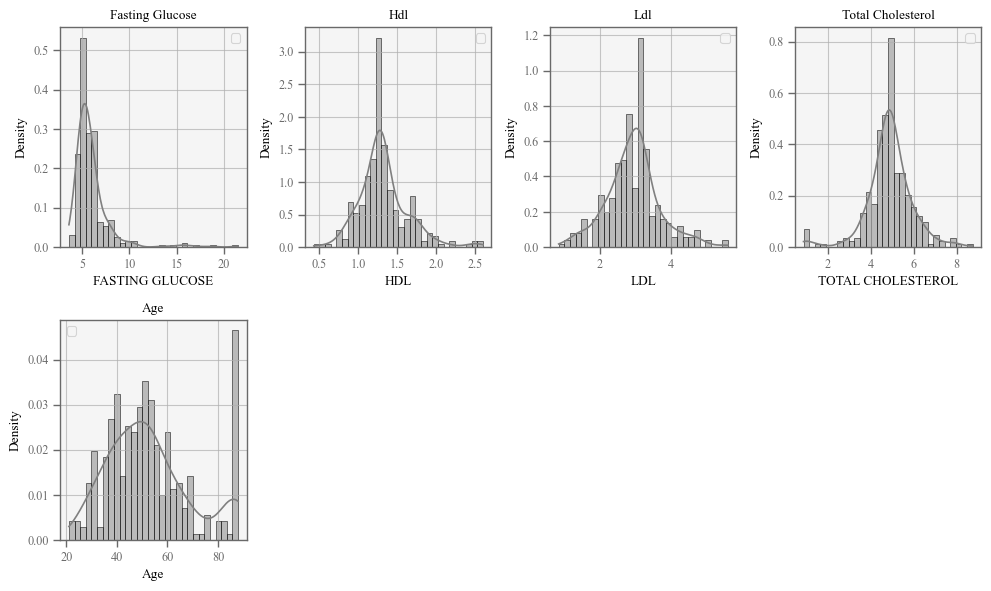

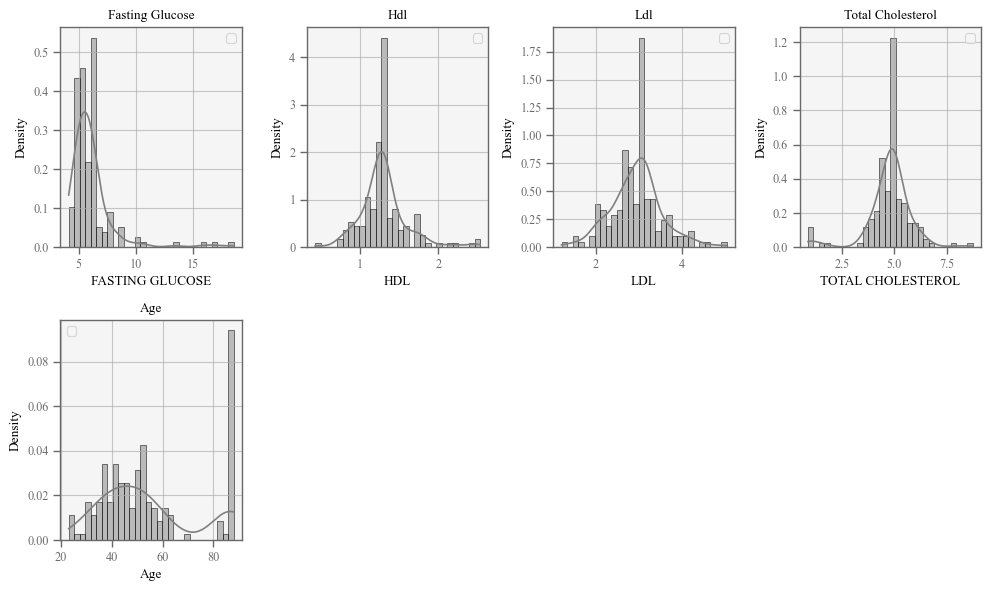

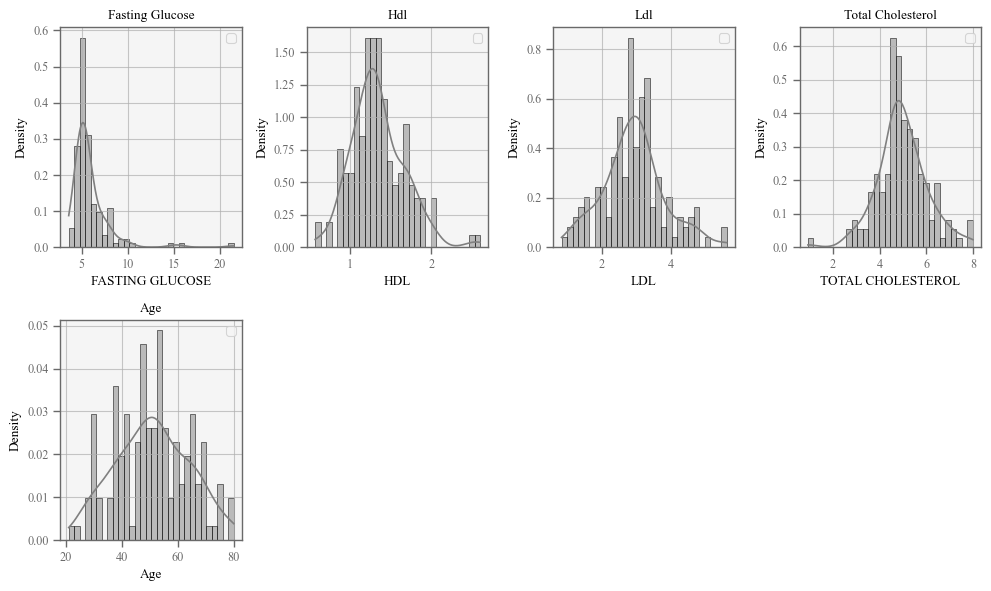

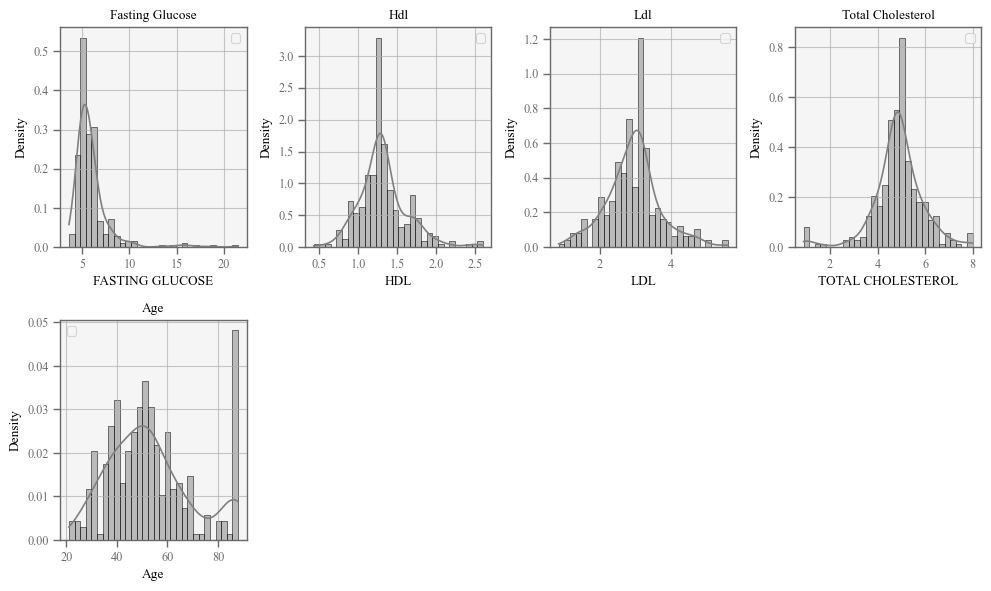

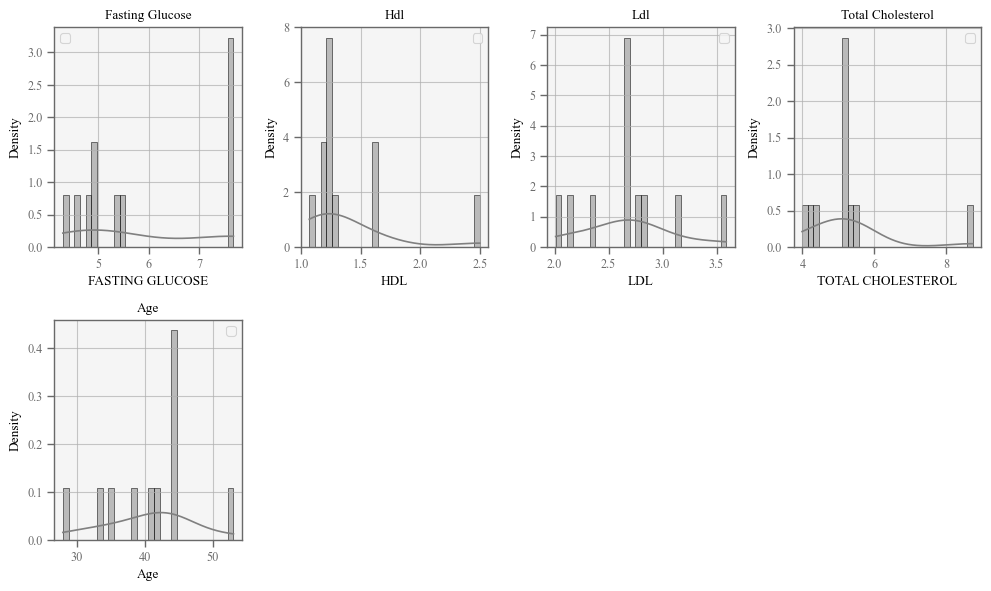

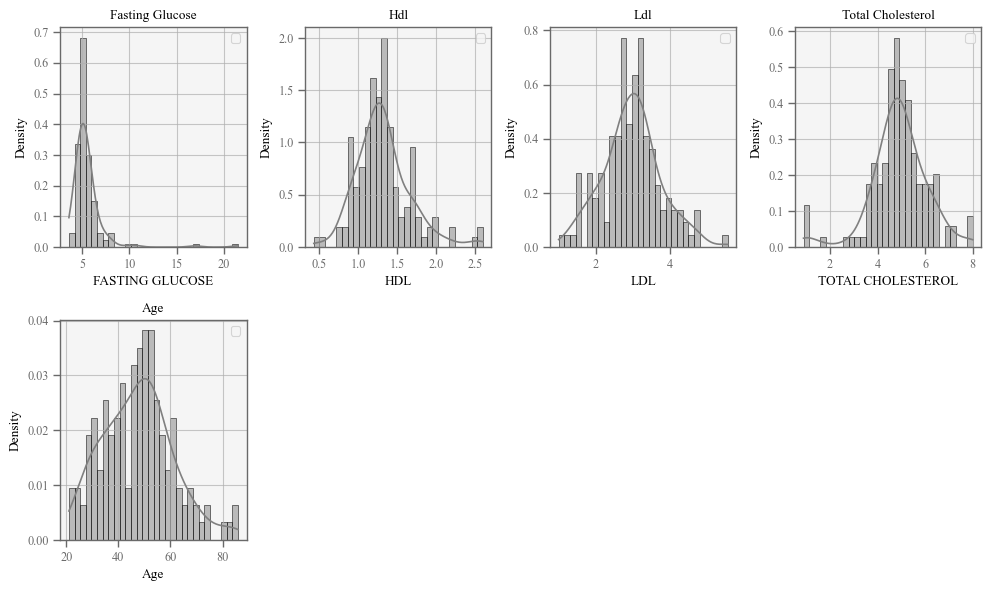

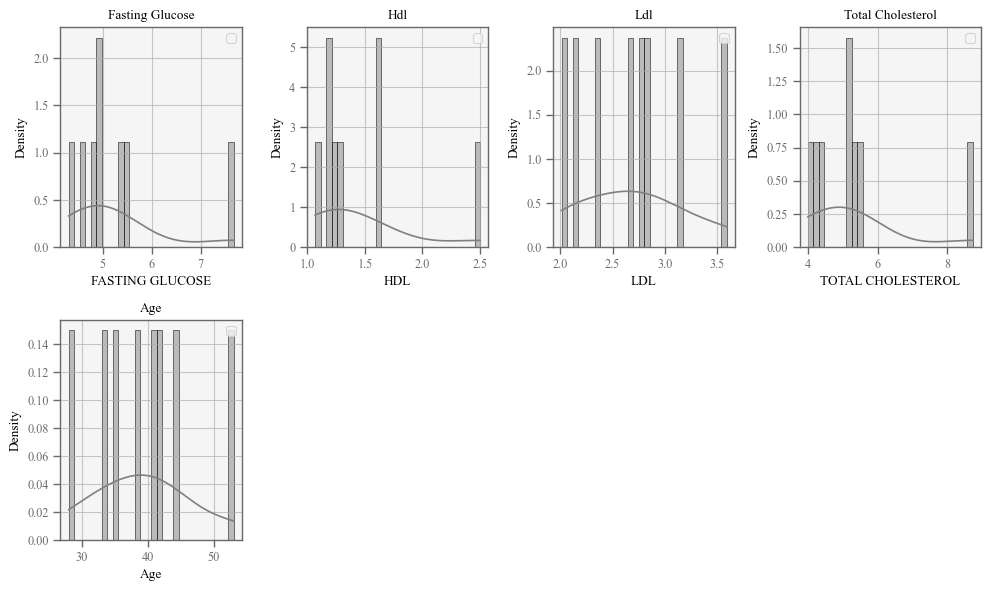

2025-07-23 18:30:30,251 - INFO - 
=== Univariate Analysis ===


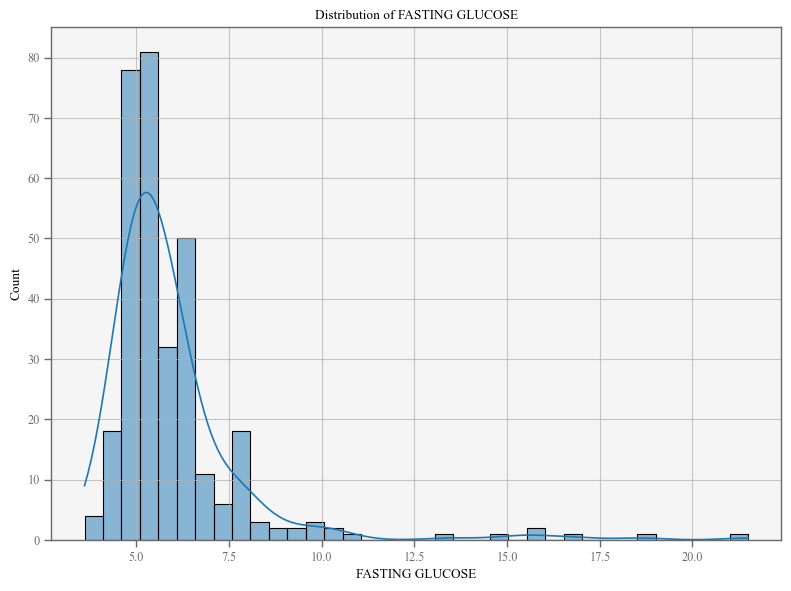

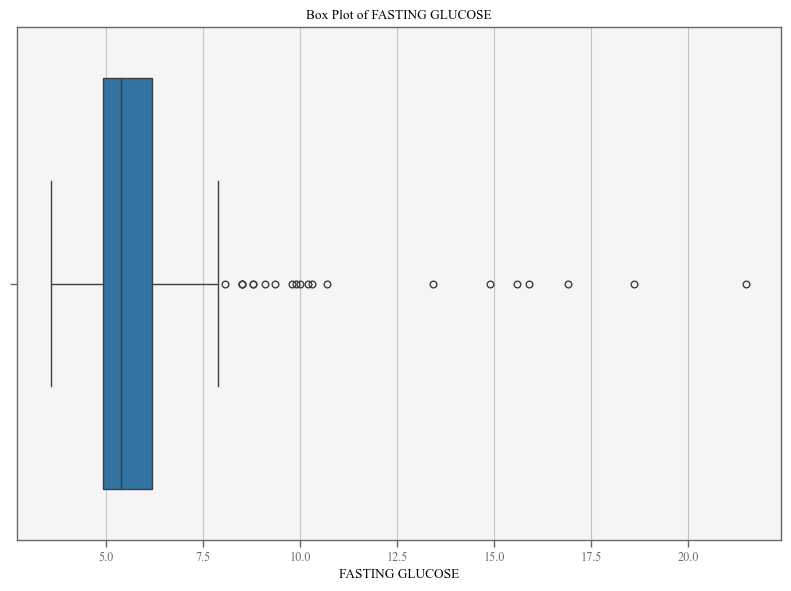

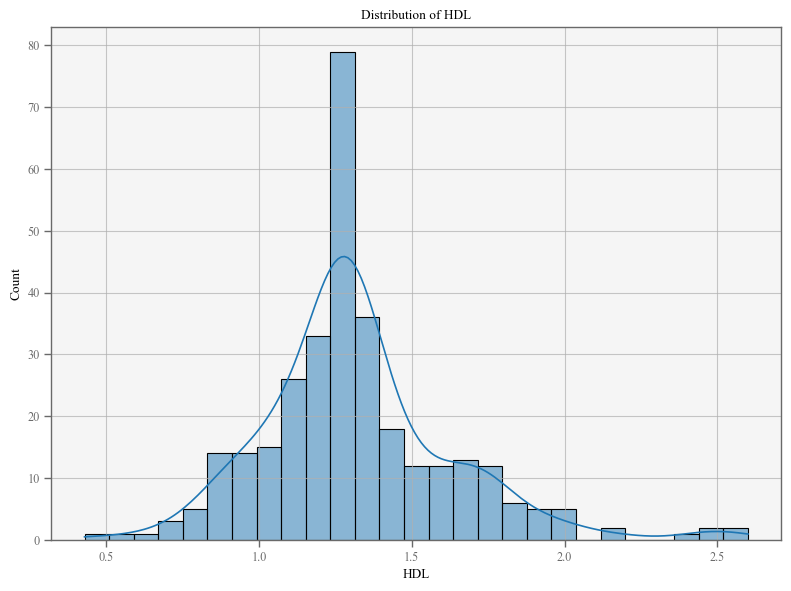

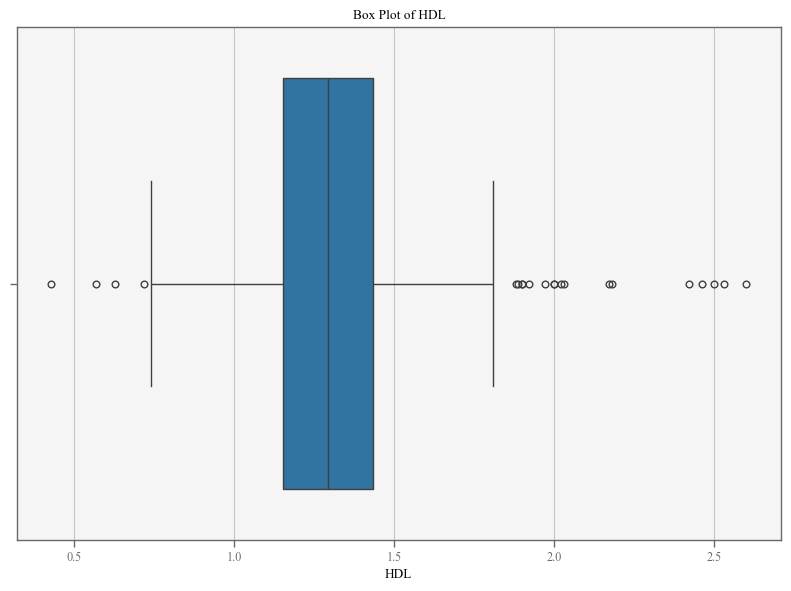

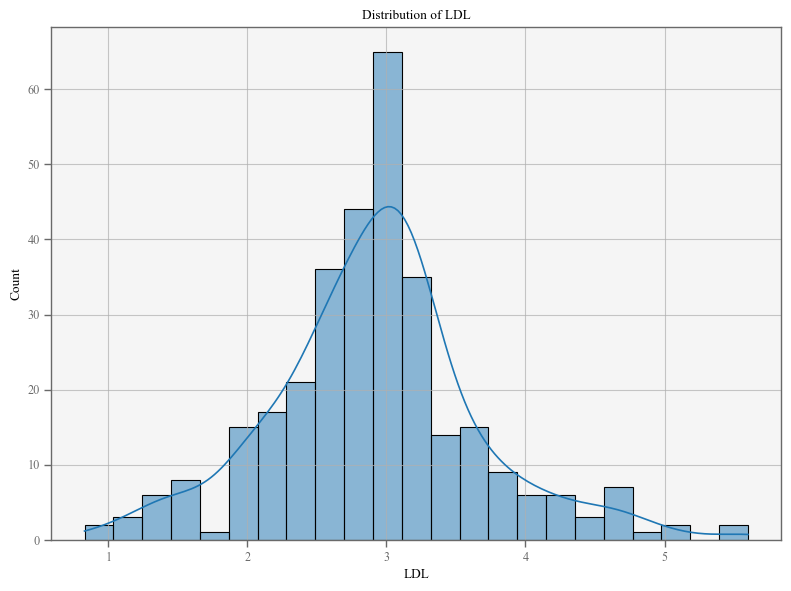

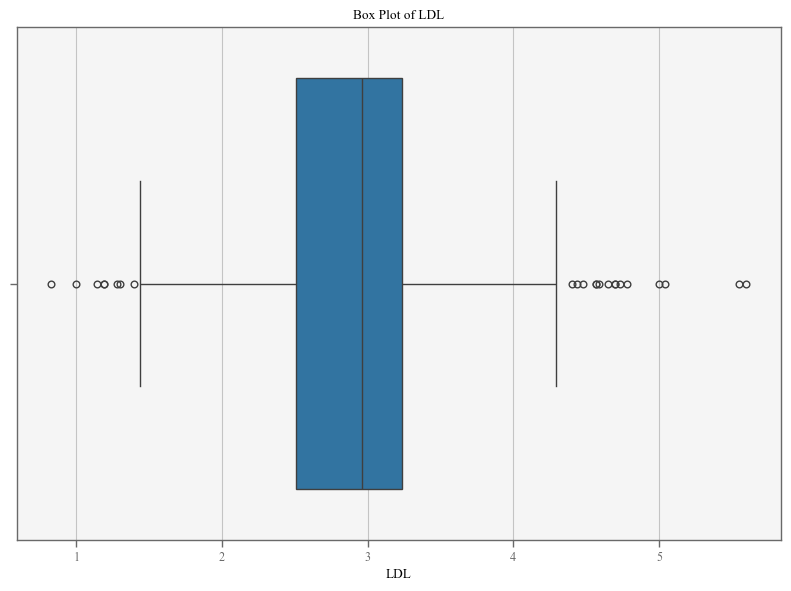

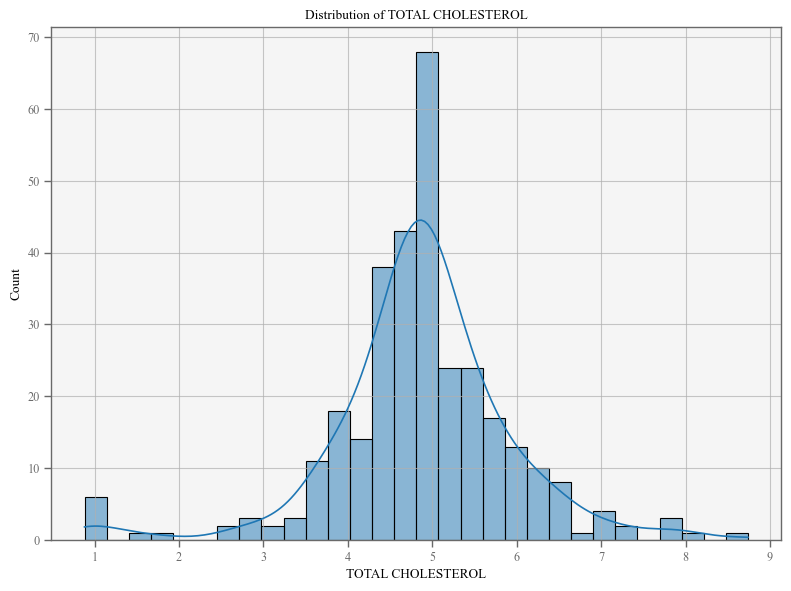

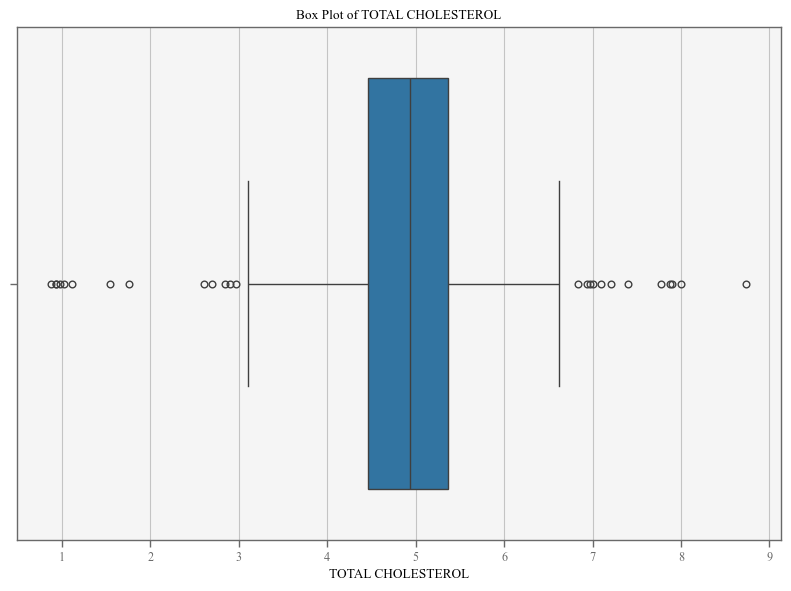

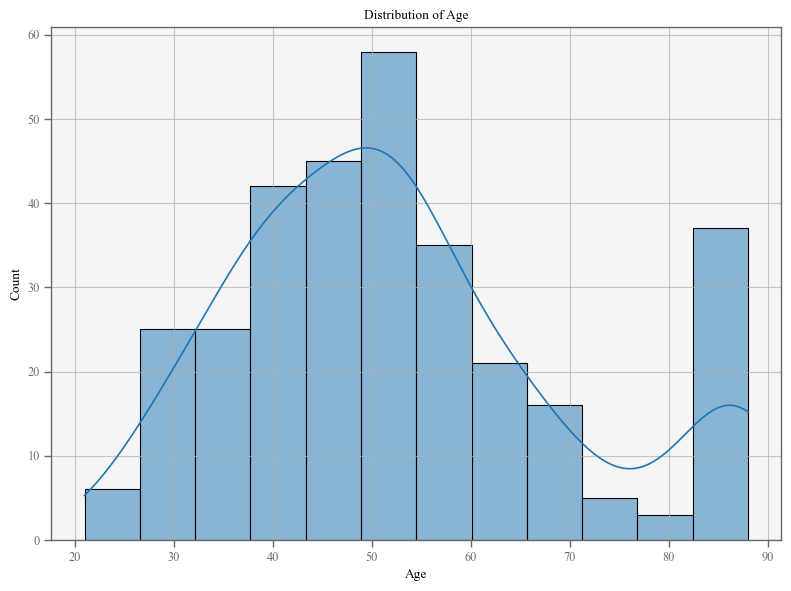

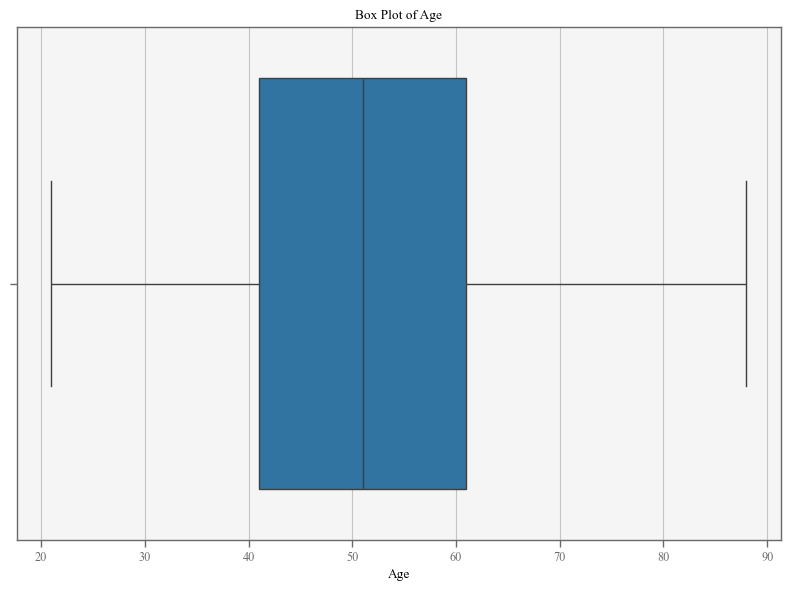

2025-07-23 18:30:33,863 - INFO - 
=== Bivariate Analysis ===
2025-07-23 18:30:33,890 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:33,904 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


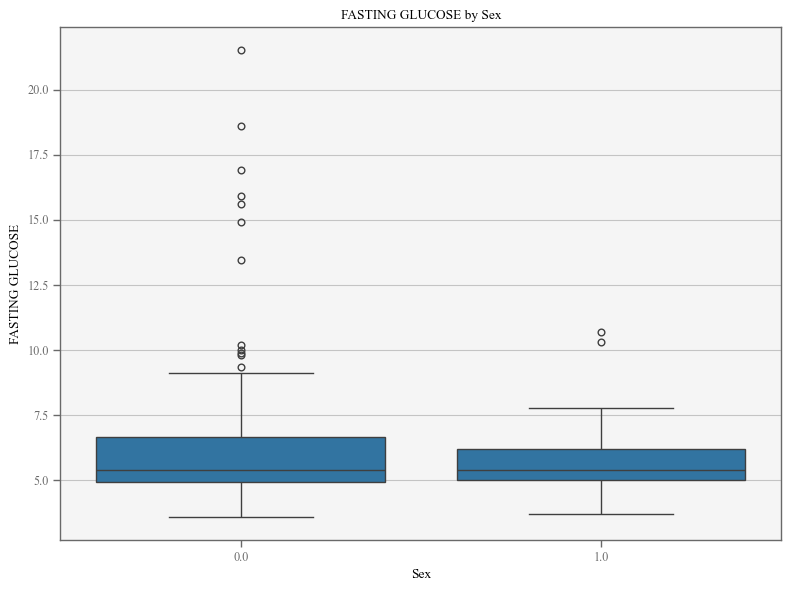

2025-07-23 18:30:34,193 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:34,206 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


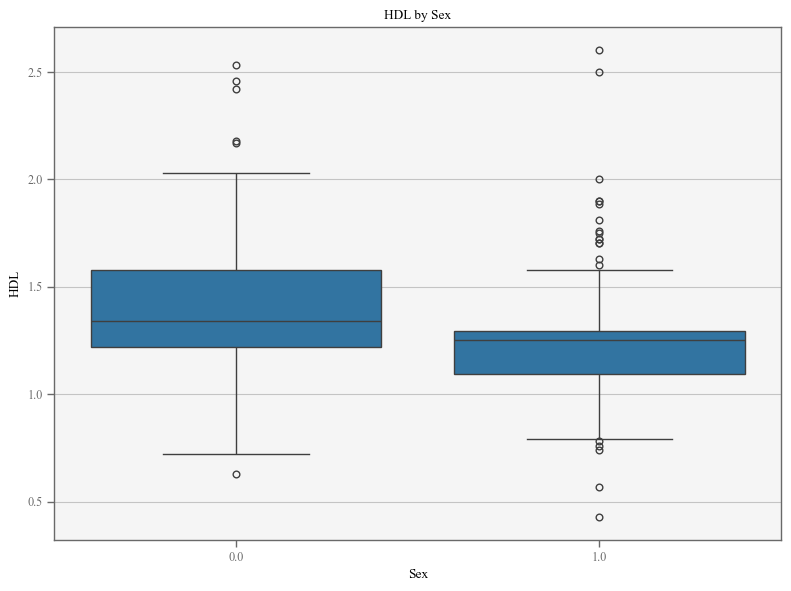

2025-07-23 18:30:34,460 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:34,474 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


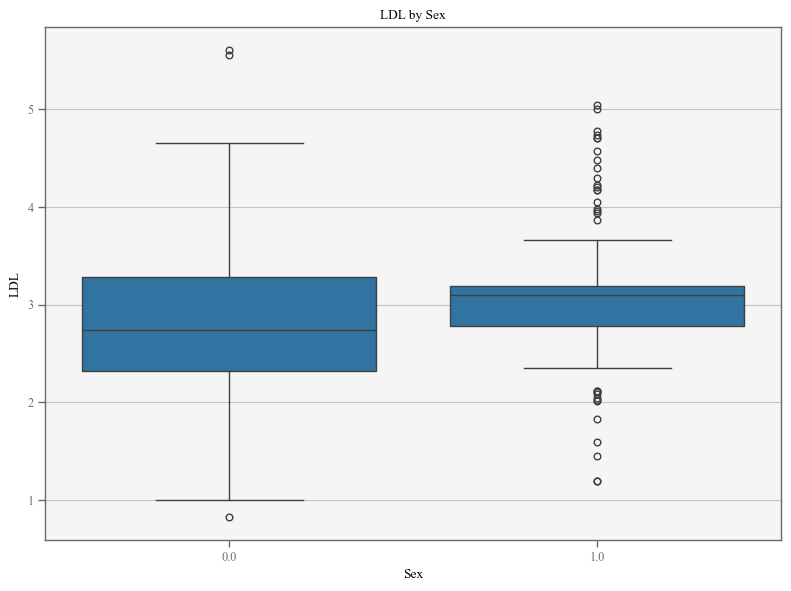

2025-07-23 18:30:34,728 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:34,740 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


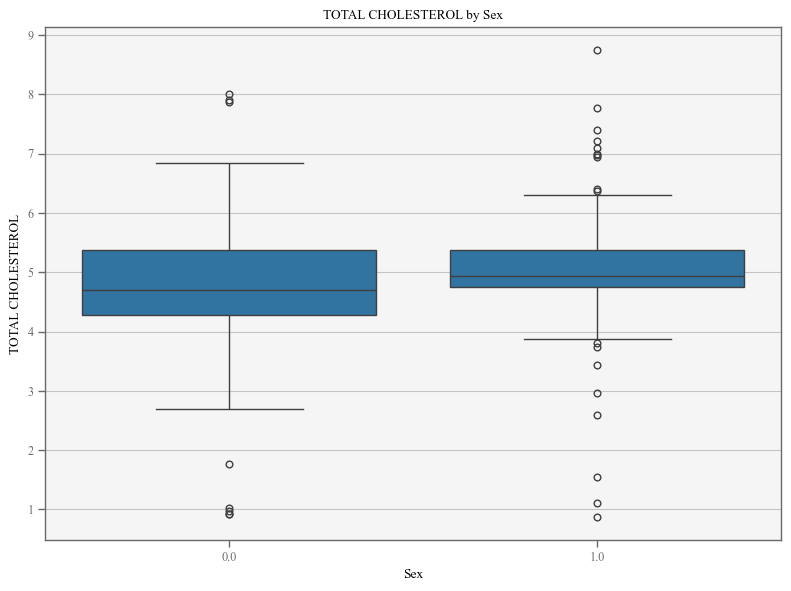

2025-07-23 18:30:35,053 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:35,067 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


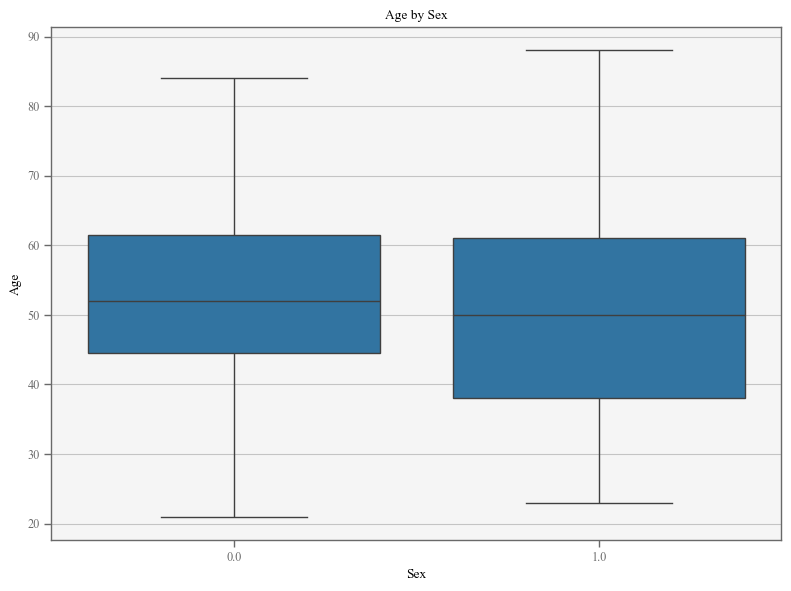

2025-07-23 18:30:35,610 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:35,625 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


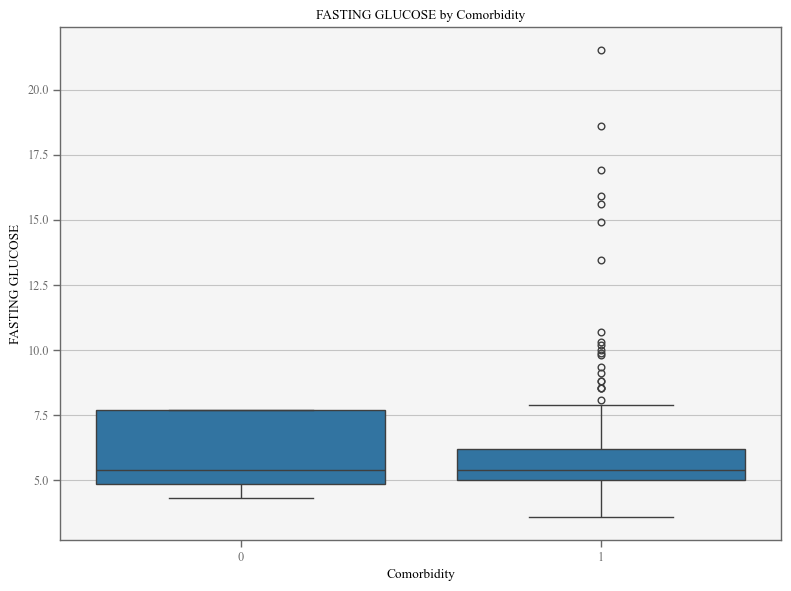

2025-07-23 18:30:35,972 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:35,994 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


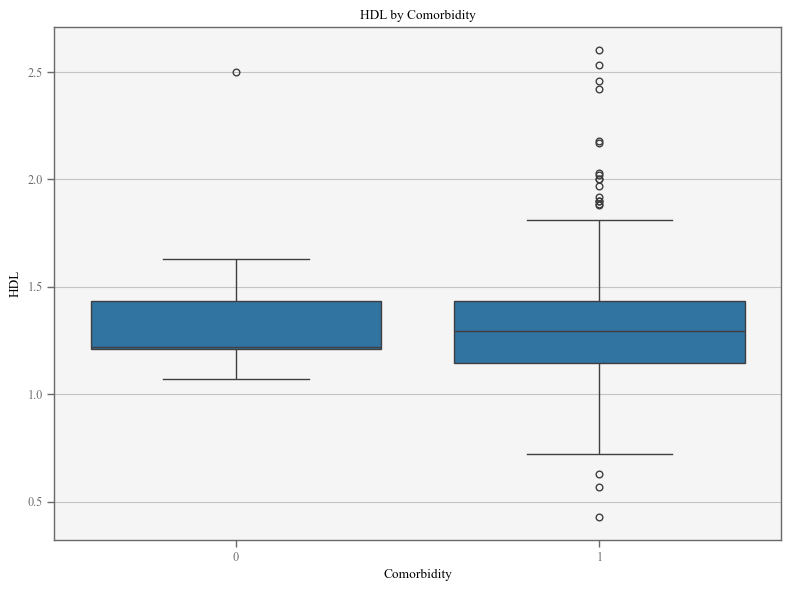

2025-07-23 18:30:36,262 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:36,275 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


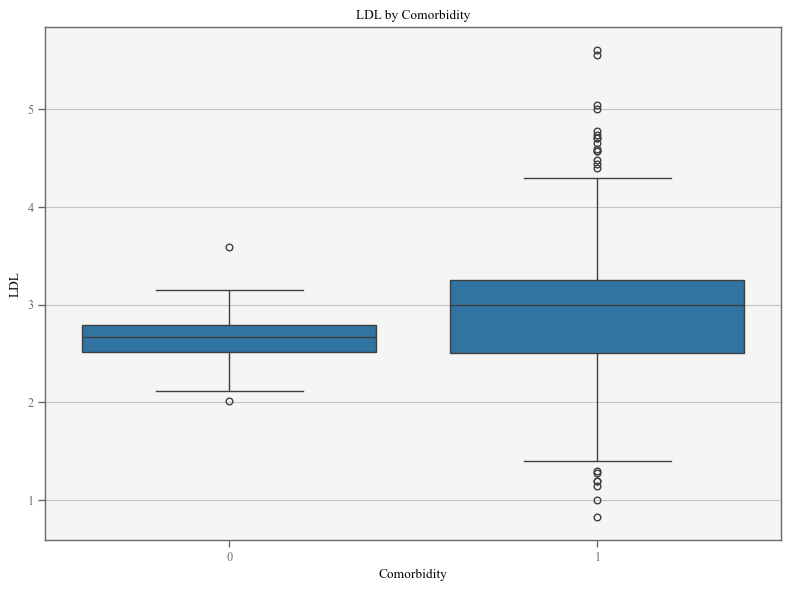

2025-07-23 18:30:36,513 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:36,528 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


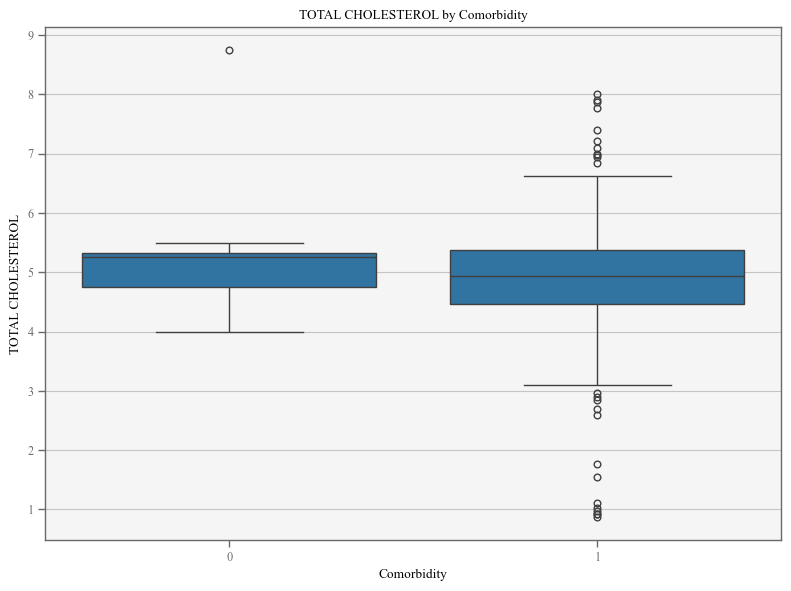

2025-07-23 18:30:36,881 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:36,893 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


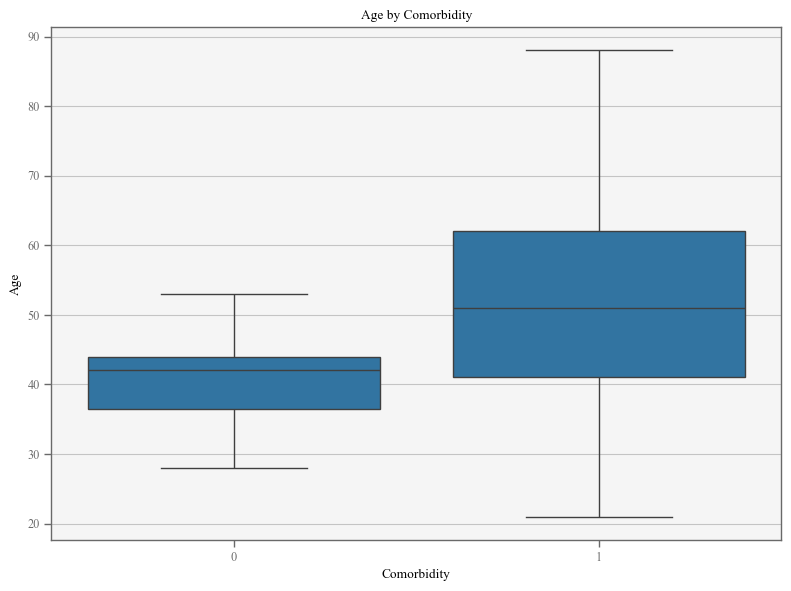

2025-07-23 18:30:37,168 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:37,181 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


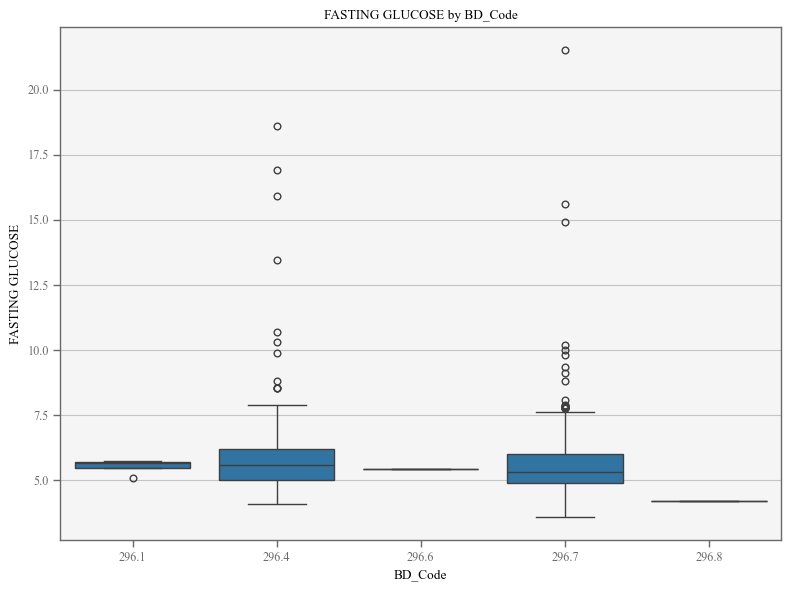

2025-07-23 18:30:37,915 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:37,927 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


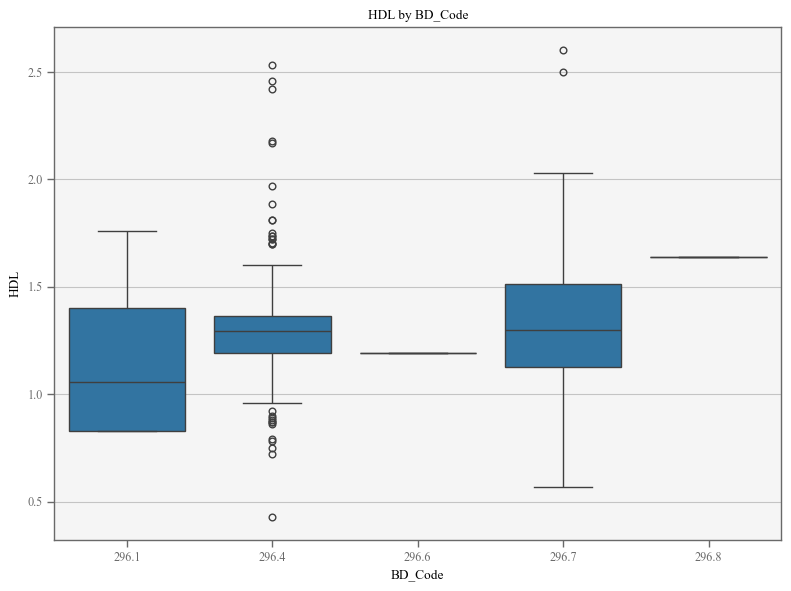

2025-07-23 18:30:38,227 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:38,241 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


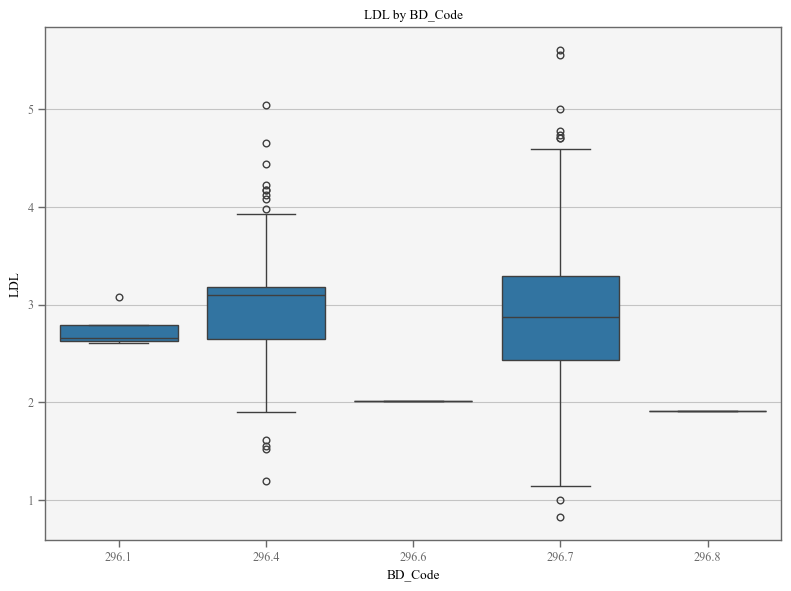

2025-07-23 18:30:38,681 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:38,697 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


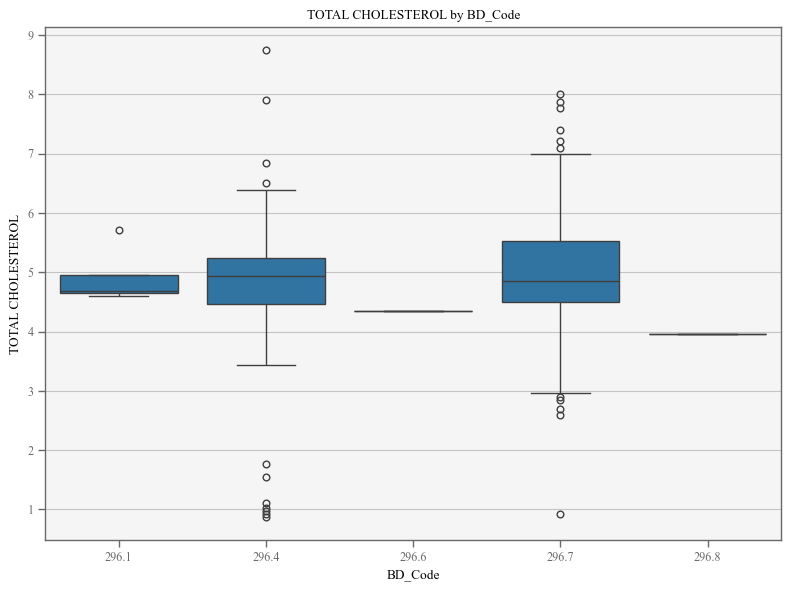

2025-07-23 18:30:39,092 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:39,105 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


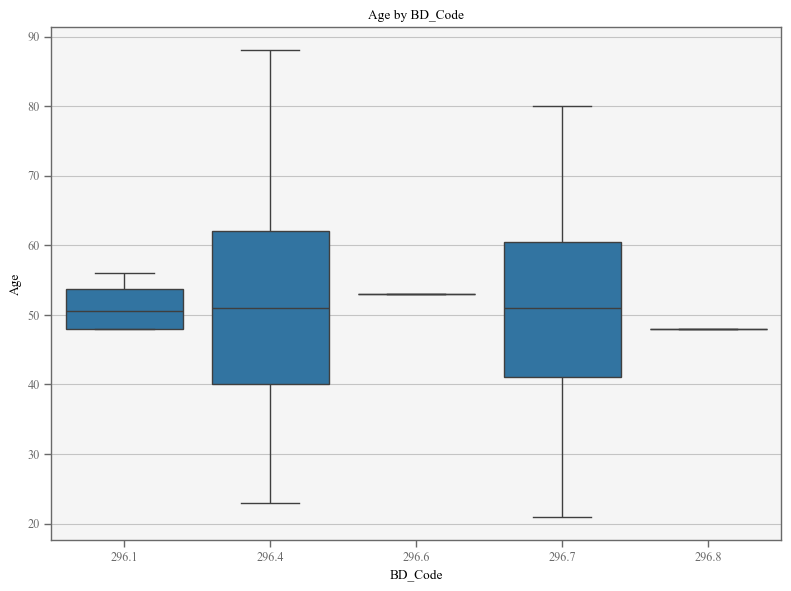

2025-07-23 18:30:39,615 - INFO - 
=== Multivariate Analysis ===


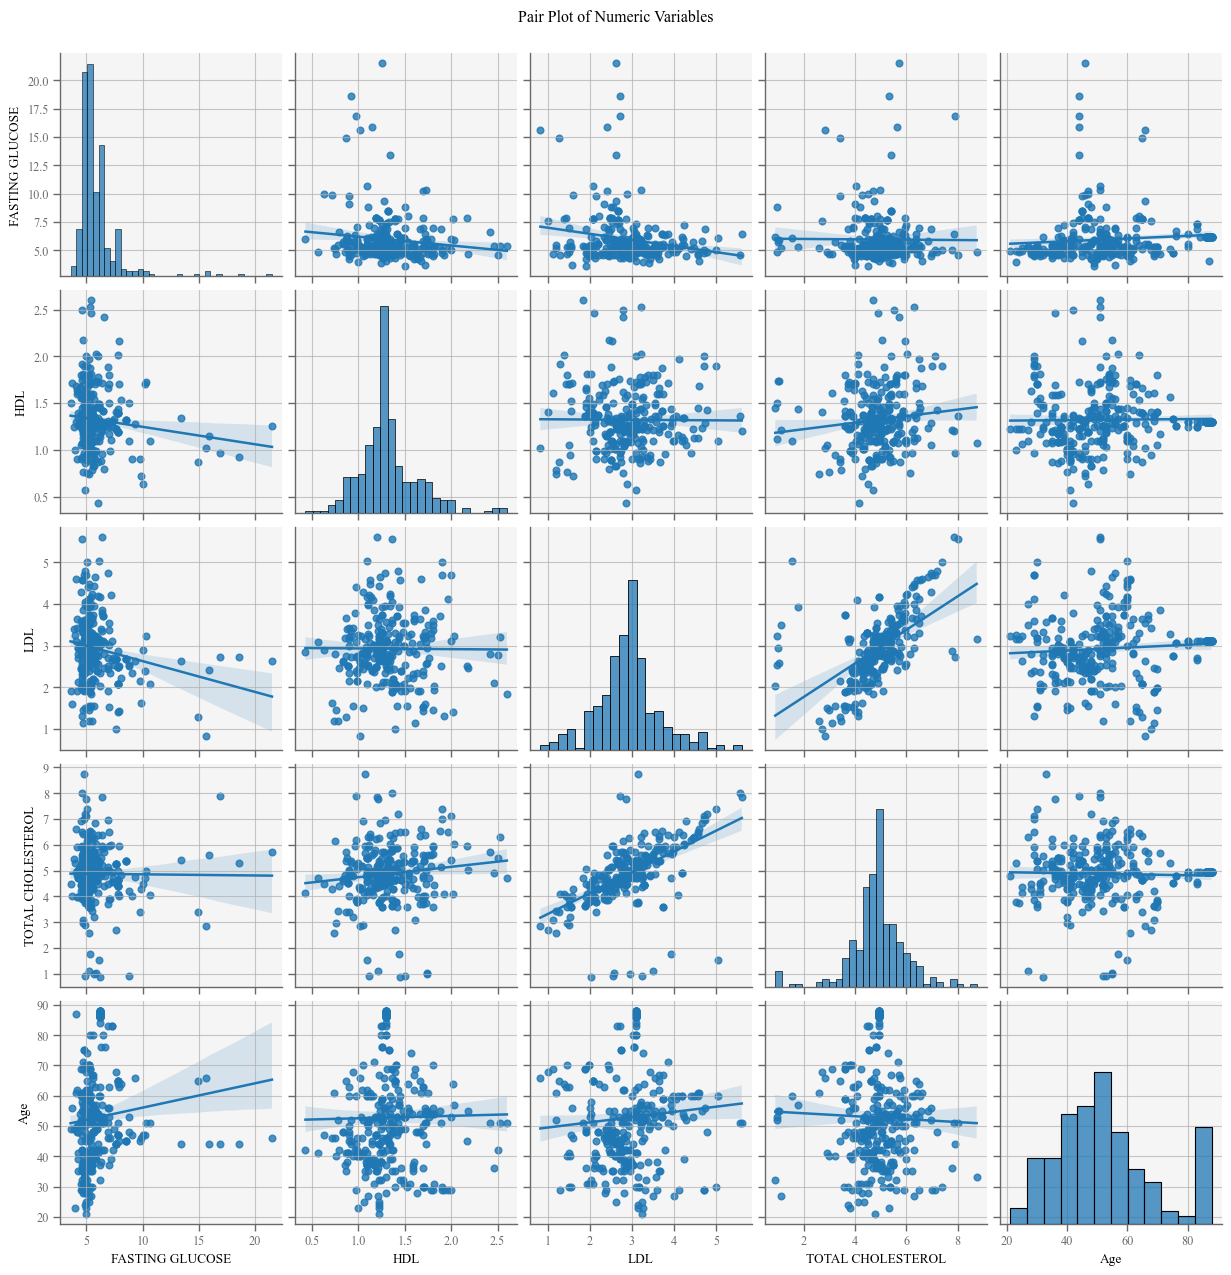

2025-07-23 18:30:51,738 - INFO - 
Pearson Correlation Matrix:
2025-07-23 18:30:51,739 - INFO -                    FASTING GLUCOSE       HDL       LDL  TOTAL CHOLESTEROL  \
FASTING GLUCOSE           1.000000 -0.120853 -0.200051          -0.008396   
HDL                      -0.120853  1.000000 -0.006864           0.118492   
LDL                      -0.200051 -0.006864  1.000000           0.570749   
TOTAL CHOLESTEROL        -0.008396  0.118492  0.570749           1.000000   
Age                       0.097401  0.014874  0.077338          -0.030740   

                        Age  
FASTING GLUCOSE    0.097401  
HDL                0.014874  
LDL                0.077338  
TOTAL CHOLESTEROL -0.030740  
Age                1.000000  


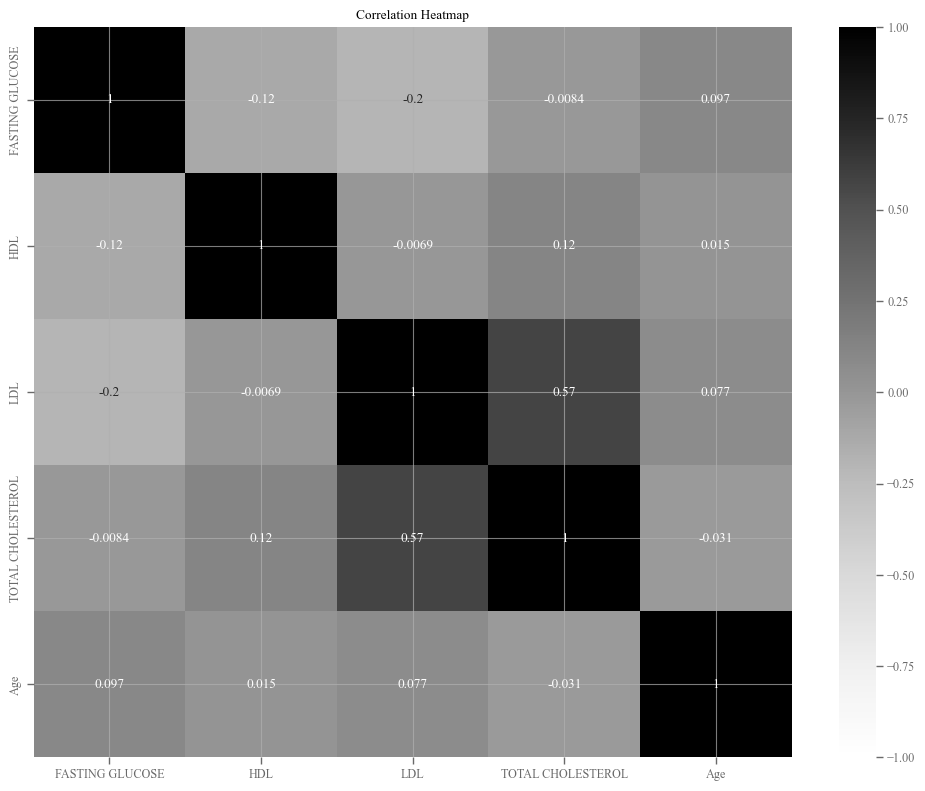

2025-07-23 18:30:52,218 - INFO - Pearson correlation between FASTING GLUCOSE and HDL: -0.1209
2025-07-23 18:30:52,223 - INFO - Spearman correlation between FASTING GLUCOSE and HDL: -0.0501
2025-07-23 18:30:52,226 - INFO - Pearson correlation between FASTING GLUCOSE and LDL: -0.2001
2025-07-23 18:30:52,230 - INFO - Spearman correlation between FASTING GLUCOSE and LDL: -0.1232
2025-07-23 18:30:52,233 - INFO - Pearson correlation between FASTING GLUCOSE and TOTAL CHOLESTEROL: -0.0084
2025-07-23 18:30:52,240 - INFO - Spearman correlation between FASTING GLUCOSE and TOTAL CHOLESTEROL: 0.0076
2025-07-23 18:30:52,244 - INFO - Pearson correlation between FASTING GLUCOSE and Age: 0.0974
2025-07-23 18:30:52,248 - INFO - Spearman correlation between FASTING GLUCOSE and Age: 0.2958
2025-07-23 18:30:52,252 - INFO - Pearson correlation between HDL and LDL: -0.0069
2025-07-23 18:30:52,256 - INFO - Spearman correlation between HDL and LDL: -0.0099
2025-07-23 18:30:52,259 - INFO - Pearson correlation b

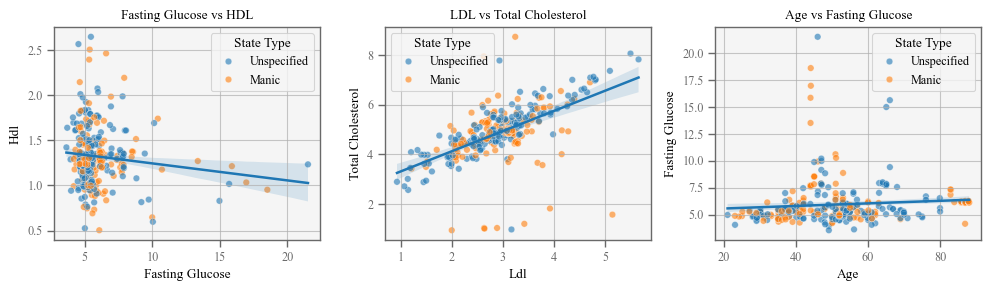

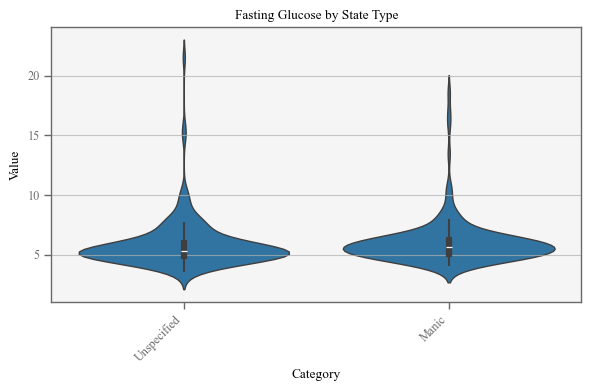

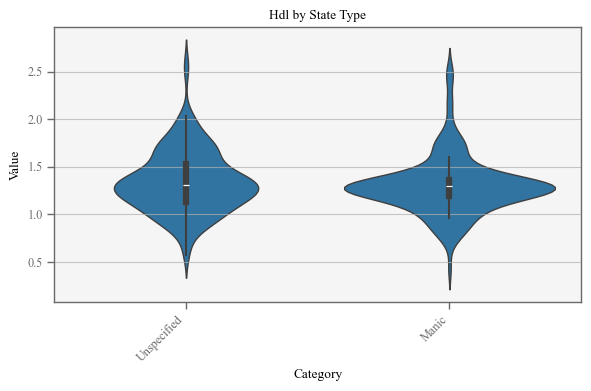

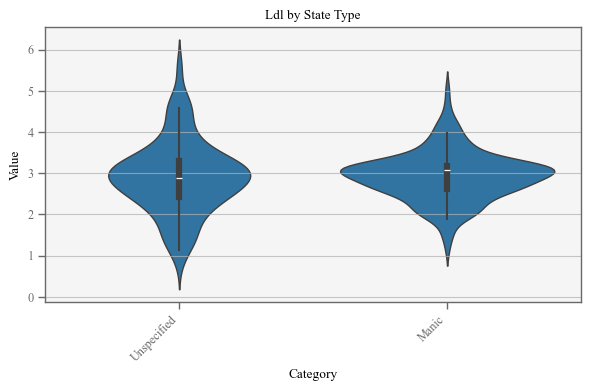

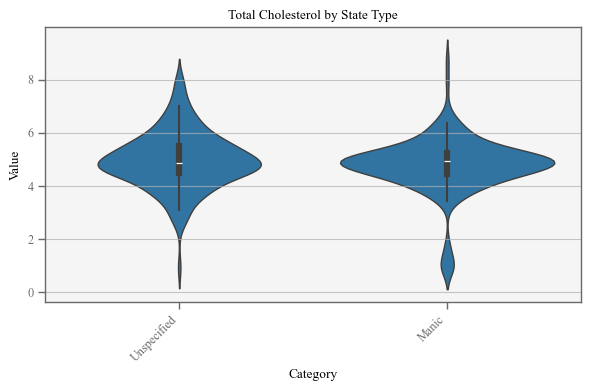

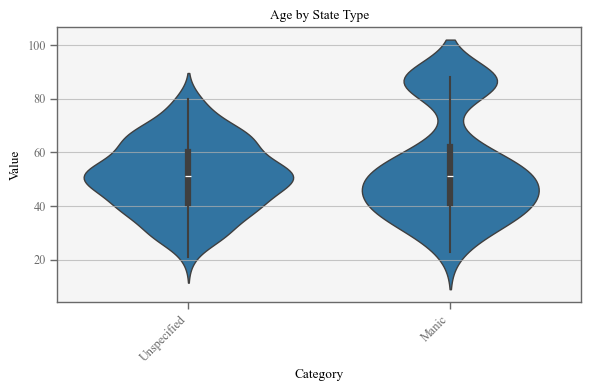

2025-07-23 18:30:55,300 - INFO - 
=== Levene's Test for FASTING GLUCOSE ===
2025-07-23 18:30:55,302 - INFO - Statistic: 0.0038
2025-07-23 18:30:55,304 - INFO - P-value: 9.5084e-01
2025-07-23 18:30:55,306 - INFO - Fail to reject null hypothesis: Variances are equal for FASTING GLUCOSE between Manic and Unspecified
2025-07-23 18:30:55,311 - INFO - 
=== Levene's Test for HDL ===
2025-07-23 18:30:55,312 - INFO - Statistic: 4.9096
2025-07-23 18:30:55,313 - INFO - P-value: 2.7420e-02
2025-07-23 18:30:55,314 - INFO - Reject null hypothesis: Variances are unequal for HDL between Manic and Unspecified
2025-07-23 18:30:55,319 - INFO - 
=== Levene's Test for LDL ===
2025-07-23 18:30:55,320 - INFO - Statistic: 13.8165
2025-07-23 18:30:55,321 - INFO - P-value: 2.3835e-04
2025-07-23 18:30:55,321 - INFO - Reject null hypothesis: Variances are unequal for LDL between Manic and Unspecified
2025-07-23 18:30:55,327 - INFO - 
=== Levene's Test for TOTAL CHOLESTEROL ===
2025-07-23 18:30:55,328 - INFO - Sta

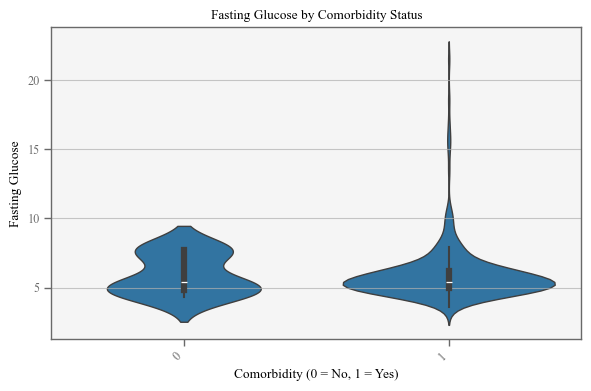

2025-07-23 18:30:56,054 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:56,083 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


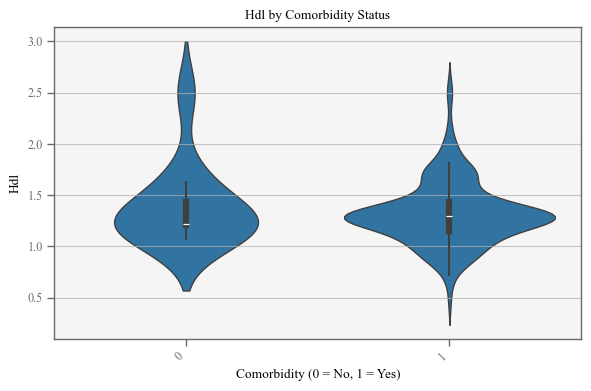

2025-07-23 18:30:57,297 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:57,326 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


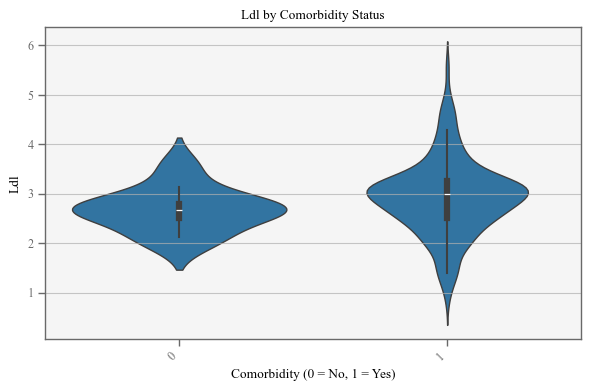

2025-07-23 18:30:58,115 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:58,129 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


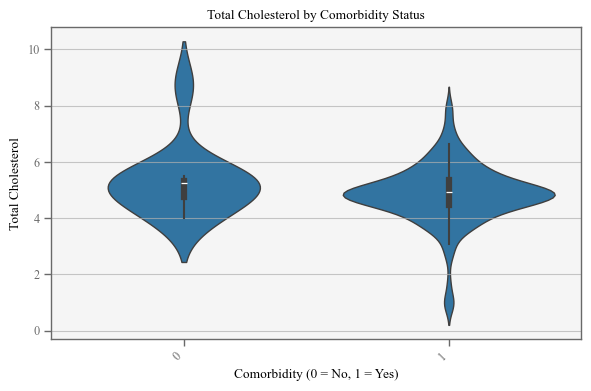

2025-07-23 18:30:58,852 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:30:58,874 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


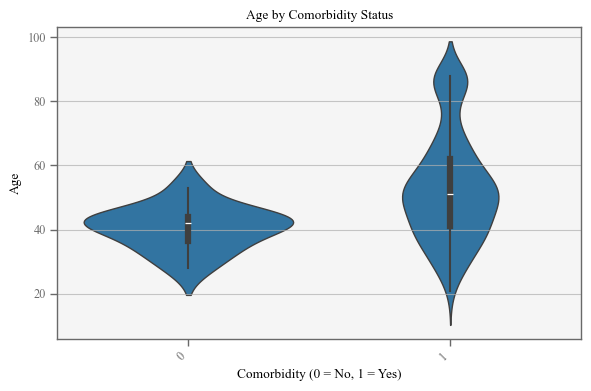

2025-07-23 18:31:00,306 - INFO - 
=== Descriptive Statistics for FASTING GLUCOSE ===
2025-07-23 18:31:00,307 - INFO - count: 11.0000
2025-07-23 18:31:00,308 - INFO - mean: 5.9145
2025-07-23 18:31:00,313 - INFO - median: 5.4000
2025-07-23 18:31:00,316 - INFO - mode: 7.6800
2025-07-23 18:31:00,319 - INFO - std: 1.4349
2025-07-23 18:31:00,320 - INFO - variance: 2.0590
2025-07-23 18:31:00,321 - INFO - skewness: 0.4892
2025-07-23 18:31:00,326 - INFO - kurtosis: -1.9006
2025-07-23 18:31:00,327 - INFO - min: 4.3000
2025-07-23 18:31:00,328 - INFO - max: 7.6800
2025-07-23 18:31:00,332 - INFO - percentile_25: 4.8500
2025-07-23 18:31:00,347 - INFO - percentile_50: 5.4000
2025-07-23 18:31:00,348 - INFO - percentile_75: 7.6800
2025-07-23 18:31:00,349 - INFO - iqr: 2.8300
2025-07-23 18:31:00,352 - INFO - missing_count: 0.0000
2025-07-23 18:31:00,366 - INFO - missing_percentage: 0.0000
2025-07-23 18:31:00,401 - INFO - 
=== Descriptive Statistics for HDL ===
2025-07-23 18:31:00,419 - INFO - count: 11.


=== Descriptive stats for No Comorbidity (Comorbidity=0) ===


2025-07-23 18:31:00,507 - INFO - mode: 2.6700
2025-07-23 18:31:00,509 - INFO - std: 0.4407
2025-07-23 18:31:00,510 - INFO - variance: 0.1942
2025-07-23 18:31:00,511 - INFO - skewness: 0.4931
2025-07-23 18:31:00,512 - INFO - kurtosis: 0.9108
2025-07-23 18:31:00,514 - INFO - min: 2.0100
2025-07-23 18:31:00,514 - INFO - max: 3.5900
2025-07-23 18:31:00,515 - INFO - percentile_25: 2.5100
2025-07-23 18:31:00,516 - INFO - percentile_50: 2.6700
2025-07-23 18:31:00,517 - INFO - percentile_75: 2.7920
2025-07-23 18:31:00,520 - INFO - iqr: 0.2820
2025-07-23 18:31:00,522 - INFO - missing_count: 0.0000
2025-07-23 18:31:00,523 - INFO - missing_percentage: 0.0000
2025-07-23 18:31:00,531 - INFO - 
=== Descriptive Statistics for TOTAL CHOLESTEROL ===
2025-07-23 18:31:00,532 - INFO - count: 11.0000
2025-07-23 18:31:00,533 - INFO - mean: 5.3095
2025-07-23 18:31:00,538 - INFO - median: 5.2540
2025-07-23 18:31:00,539 - INFO - mode: 5.2540
2025-07-23 18:31:00,539 - INFO - std: 1.2491
2025-07-23 18:31:00,540 


=== Descriptive stats for With Comorbidity (Comorbidity=1) ===


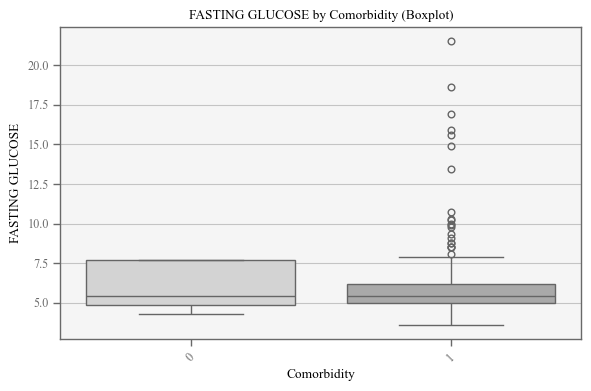

2025-07-23 18:31:01,115 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:31:01,130 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


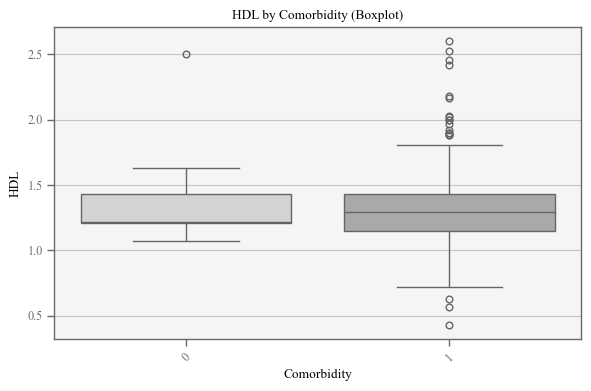

2025-07-23 18:31:01,477 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:31:01,493 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


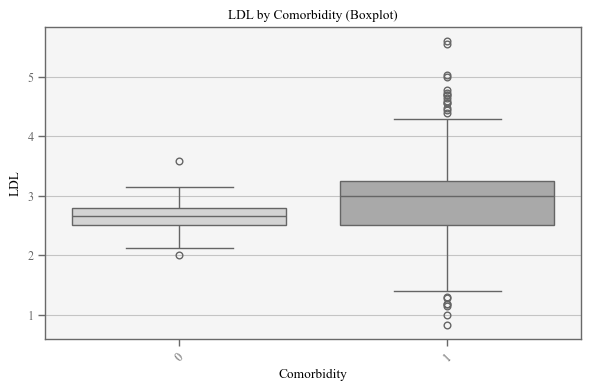

2025-07-23 18:31:01,816 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:31:01,832 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


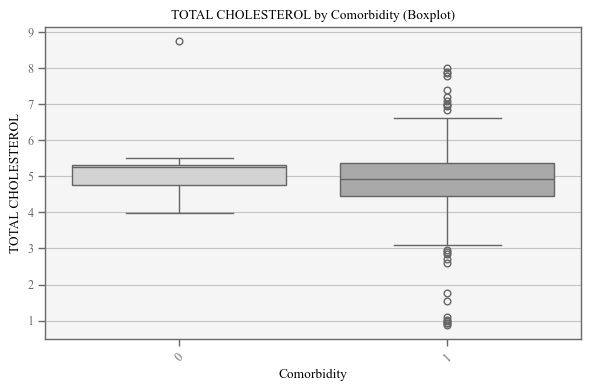

2025-07-23 18:31:02,397 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-23 18:31:02,432 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


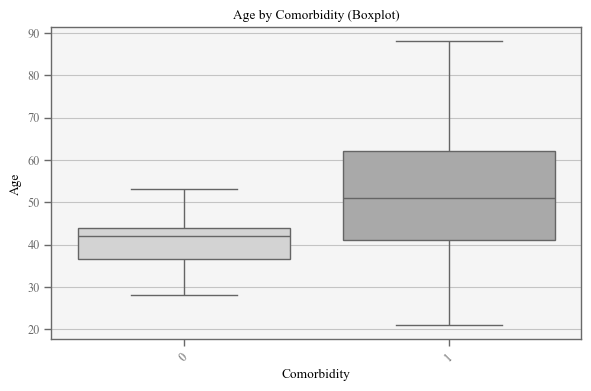

In [8]:
# Load imputed, clean dataset 
df = imp.load_data("bd_labs_imputed_within_2yrs.csv")

# Define numeric and categorical columns
numeric_cols = ['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age']
categorical_cols = ['Sex', 'Comorbidity', 'BD_Code']

# Map and encode bipolar disorder states (Manic vs Unspecified only)
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': None,            # Exclude BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Unspecified']

# Apply mapping and filter for Manic and Unspecified only
df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)

# Create subgroups for Manic and Unspecified
df_manic = df[df['State Type'] == 'Manic']
df_unspecified = df[df['State Type'] == 'Unspecified']

# 1. Summarize the DataFrame
eda.summarize_dataframes(df, name="Bipolar Disorder Dataset")

# 2. Compute descriptive statistics for subgroups 
print("\n=== Descriptive stats for manic subgroup ===")
eda.compute_descriptive_stats(df_manic, numeric_cols)
print("\n=== Descriptive stats for unspecified subgroup ===")
eda.compute_descriptive_stats(df_unspecified, numeric_cols)

# 3. Plot histograms for numeric columns to check normality (overall dataset)
eda.plot_histograms(df, numeric_cols)

# 4. Plot histograms for biomarkers for Manic subset
df_manic = df[df['State Type'] == 'Manic']
eda.plot_histograms(df_manic, numeric_cols)

# 5. Plot histograms for biomarkers for Unspecified subset
df_unspecified = df[df['State Type'] == 'Unspecified']
eda.plot_histograms(df_unspecified, numeric_cols)

#6. # Distribution by Comorbidity
eda.plot_histograms(df[df['Comorbidity'] == 1], numeric_cols)
eda.plot_histograms(df[df['Comorbidity'] == 0], numeric_cols)

#7. Distribution for same-day BD diagnosis vs. others (first lab after first BD diagnosis)
first_labs = df.groupby('Patient_ID').first().reset_index()
same_day = first_labs[first_labs['Comorbidity'] == 1]
not_same_day = first_labs[first_labs['Comorbidity'] == 0]
eda.plot_histograms(same_day, numeric_cols)
eda.plot_histograms(not_same_day, numeric_cols)

#8. Perform full correlation analysis
eda.perform_correlation_analysis(df, numeric_cols, categorical_cols)

#9. Compute correlations for multicollinearity
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        eda.compute_correlation(df, numeric_cols[i], numeric_cols[j], 'pearson')
        eda.compute_correlation(df, numeric_cols[i], numeric_cols[j], 'spearman')

# 10. Plot scatter pairs for key numeric variables only
col_pairs = [
    ('FASTING GLUCOSE', 'HDL', 'Fasting Glucose vs HDL'),
    ('LDL', 'TOTAL CHOLESTEROL', 'LDL vs Total Cholesterol'),
    ('Age', 'FASTING GLUCOSE', 'Age vs Fasting Glucose')
]
eda.plot_scatter_pairs(df, col_pairs, hue_col='State Type', jitter=0.1, alpha=0.6, figsize=(10, 3))

# 11. Plot violin charts for biomarkers by State Type
for col in numeric_cols:
    eda.plot_violin_chart(df, x_col='State Type', y_col=col, 
                         title=f"{col.replace('_', ' ').title()} by State Type")

# 12. Perform Levene's test for variance equality between Manic and Unspecified groups
eda.perform_levene_test(df, numeric_cols, group_col='State Type', group1='Manic', group2='Unspecified', alpha=0.05)

# 13. Plot violin charts for biomarkers and age by Comorbidity
for col in numeric_cols:
    eda.plot_violin_chart(
        df=df,
        x_col='Comorbidity',
        y_col=col,
        title=f"{col.replace('_', ' ').title()} by Comorbidity Status",
        xlabel="Comorbidity (0 = No, 1 = Yes)",
        ylabel=col.replace('_', ' ').title(),
        figsize=(6, 4)
    )

# 14. Compute descriptive stats by comorbidity 
print("\n=== Descriptive stats for No Comorbidity (Comorbidity=0) ===")
eda.compute_descriptive_stats(df[df['Comorbidity'] == 0], numeric_cols)
print("\n=== Descriptive stats for With Comorbidity (Comorbidity=1) ===")
eda.compute_descriptive_stats(df[df['Comorbidity'] == 1], numeric_cols)

# 15. Plot box plots for biomarkers and age by Comorbidity
for col in numeric_cols:
    em.plot_by_group(
        df=df,
        y_vars=[col],
        x='Comorbidity',
        hue=None,
        plot_type='box',
        palette=['#D3D3D3', '#A9A9A9'], 
        figsize=(6, 4),
        bins=20,
        kde=True
    )




=== Cross-Tabulation: Comorbidity vs. State Type ===


2025-07-23 18:40:55,883 - INFO - 
=== Cross-Tabulation ===
2025-07-23 18:40:55,887 - INFO - State Type   Manic  Unspecified  Total
Comorbidity                           
0                9            2     11
1              153          154    307
Total          162          156    318


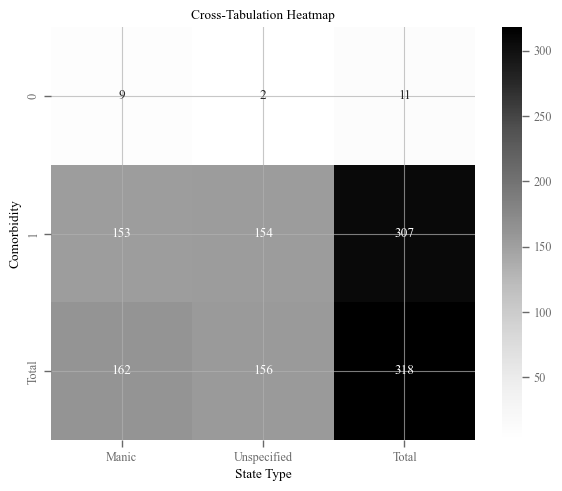

In [9]:
print("\n=== Cross-Tabulation: Comorbidity vs. State Type ===")
crosstab_result = eda.create_crosstab(
    df=df,
    index='Comorbidity',
    columns='State Type',
    values=None,
    aggfunc=None,
    normalize=False,
    margins=True,
    margins_name='Total',
    figsize=(6, 5)
)